# V2 Analysis: Does the Size of a Team's Largest Contract Predict Net Rating Change?

**Goal:** Use the same teams and contracts from V1, but swap the outcome metric from win rate to **net rating** — a more precise measure of how well a team actually plays.

**What is net rating?**  
Points scored minus points allowed, per 100 possessions. A team with +5.0 outscores opponents by 5 points every 100 possessions. It captures *quality of play* better than win rate, which can be distorted by close games, luck, and schedule strength.

**The two questions we answer:**
- Does a team's net rating improve *after* signing their largest contract?
- Does a *larger* contract predict a *larger* improvement in net rating?

---
## Block 1 — Imports and Settings

- Same libraries and `WINDOW` setting as V1
- Change `WINDOW` to `1` or `2` to switch the before/after comparison window
- All paths point to the `data/` folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── KEY SETTING ──────────────────────────────────────────────────────
# Change this to 1 or 2 to switch between window sizes
WINDOW = 1   # seasons before AND after the contract start year
# ─────────────────────────────────────────────────────────────────────

DATA_DIR = 'data/'

print(f'Window size set to: {WINDOW} season(s) before and after contract start')

Window size set to: 1 season(s) before and after contract start


---
## Block 2 — Load the Data

- Same two files as V1: contracts and team boxscores
- We need the team boxscore for points scored and points allowed, which we'll use to calculate net rating

In [2]:
contracts_raw = pd.read_csv(DATA_DIR + 'NBA_Contracts.csv')
boxscore_raw  = pd.read_csv(DATA_DIR + 'nba_team_boxscore.csv')

print('Contracts shape:', contracts_raw.shape)
print('Team boxscore shape:', boxscore_raw.shape)

Contracts shape: (583, 11)
Team boxscore shape: (14880, 57)


---
## Block 3 — Clean the Contracts Data

- Identical cleaning to V1: fix the team column, parse AAV to a float, drop coaches
- **New here:** a manual abbreviation map that fixes `NOP → NO` and `NYK → NY`
  - These two teams were silently dropped in V1 because their abbreviations didn't match the boxscore
  - This fix adds them back in for a cleaner sample

In [3]:
contracts = contracts_raw.copy()

# Clean column names
contracts.columns = contracts.columns.str.strip()
contracts = contracts.rename(columns={'Team                     Currently With': 'Team'})

# Extract just the first abbreviation from the team column (e.g. 'MEM   MEM' -> 'MEM')
contracts['Team'] = contracts['Team'].str.strip().str.split().str[0]

# Fix abbreviations that don't match the boxscore file
abbrev_fix = {
    'NOP': 'NO',
    'NYK': 'NY',
}
contracts['Team'] = contracts['Team'].replace(abbrev_fix)

# Convert AAV from string like '$62,786,682' to a float
contracts['AAV_clean'] = (
    contracts['AAV']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Drop coaches
contracts = contracts[contracts['Pos'] != 'COA'].copy()

print('Cleaned contracts shape:', contracts.shape)
print('\nSample rows:')
contracts[['Player', 'Team', 'Pos', 'Start', 'AAV_clean']].head(8)

Cleaned contracts shape: (582, 12)

Sample rows:


,Player,Team,Pos,Start,AAV_clean
0,Jayson Tatum,BOS,PF,2025,62786682.0
1,Jaylen Brown,BOS,SF,2024,57078728.0
2,Nikola Jokic,DEN,C,2023,55224526.0
3,Shai Gilgeous-Alexander,OKC,PG,2027,67914000.0
4,Evan Mobley,CLE,PF,2025,53817156.0
5,Cade Cunningham,DET,PG,2025,53817156.0
6,Anthony Edwards,MIN,SG,2024,48924624.0
7,Tyrese Haliburton,IND,PG,2024,48924624.0


---
## Block 4 — Find Each Team's Largest Contract (by AAV)

- Identical logic to V1: one row per team, highest AAV wins
- Filter to contracts with a start year between 2021 and 2024 so both before and after data exists

In [4]:
# For each team, get the row with the highest AAV
idx = contracts.groupby('Team')['AAV_clean'].idxmax()
top_contracts = contracts.loc[idx].copy()

# Drop contracts where we don't have before/after data
top_contracts = top_contracts[top_contracts['Start'] <= 2024].copy()
top_contracts = top_contracts[top_contracts['Start'] >= 2021].copy()

top_contracts = top_contracts.reset_index(drop=True)

print(f'Teams with usable top contracts: {len(top_contracts)}')
print('\nTop contract per team:')
top_contracts[['Team', 'Player', 'Pos', 'Start', 'AAV_clean']].sort_values('AAV_clean', ascending=False)

Teams with usable top contracts: 13

Top contract per team:


,Team,Player,Pos,Start,AAV_clean
3,DEN,Nikola Jokic,C,2023,55224526.0
10,NY,Karl-Anthony Towns,C,2024,55110496.0
6,LAC,Kawhi Leonard,SF,2024,49835267.0
5,IND,Tyrese Haliburton,PG,2024,48924624.0
8,MIN,Anthony Edwards,SG,2024,48924624.0
4,HOU,Kevin Durant,SF,2022,48554830.0
12,SAC,Domantas Sabonis,PF,2024,46504000.0
2,CHA,LaMelo Ball,PG,2024,40770520.0
7,MEM,Ja Morant,PG,2023,39446090.0
9,NO,Zion Williamson,PF,2023,39446090.0


---
## Block 5 — Clean the Boxscore and Keep Regular Season Only

- Keep only regular season games (`season_type == 2`) — same as V1
- We need `team_score` (points scored) and `opponent_team_score` (points allowed) per game
- Net rating will be calculated per season in the next block

In [5]:
boxscore = boxscore_raw.copy()

# Keep only regular season games
boxscore = boxscore[boxscore['season_type'] == 2].copy()

print('Regular season games shape:', boxscore.shape)
print('Seasons available:', sorted(boxscore['season'].unique()))
print('\nSample rows:')
boxscore[['game_id', 'season', 'team_abbreviation', 'team_score', 'opponent_team_score']].head(6)

Regular season games shape: (13824, 57)
Seasons available: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sample rows:


,game_id,season,team_abbreviation,team_score,opponent_team_score
168,401224790,2020,PHI,134,96
169,401224790,2020,HOU,96,134
170,401224792,2020,OKC,103,107
171,401224792,2020,LAC,107,103
172,401224791,2020,MIA,92,109
173,401224791,2020,IND,109,92


---
## Block 6 — Calculate Net Rating Per Team Per Season

- For each team-season, sum up total points scored and total points allowed
- **Net rating formula:** `(points_scored - points_allowed) / games_played`
- This gives us an average point differential per game — a reliable proxy for true net rating
- Note: true net rating uses possessions as the denominator, but we don't have possession data in this file. Point differential per game is a very close approximation and tells the same story.

In [6]:
net_ratings = (
    boxscore
    .groupby(['team_abbreviation', 'season'])
    .agg(
        games          = ('game_id', 'count'),
        points_scored  = ('team_score', 'sum'),
        points_allowed = ('opponent_team_score', 'sum')
    )
    .reset_index()
)

net_ratings['net_rating'] = (
    (net_ratings['points_scored'] - net_ratings['points_allowed']) / net_ratings['games']
)

print('Net rating table shape:', net_ratings.shape)
print('\nSample rows:')
net_ratings.head(10)

Net rating table shape: (196, 6)

Sample rows:


,team_abbreviation,season,games,points_scored,points_allowed,net_rating
0,ATL,2020,67,7488,8022,-7.970149
1,ATL,2021,70,7958,7814,2.057143
2,ATL,2022,82,9343,9215,1.560976
3,ATL,2023,82,9711,9687,0.292683
4,ATL,2024,82,9703,9882,-2.182927
5,ATL,2025,75,8827,8965,-1.840000
6,BKN,2020,72,8048,8089,-0.569444
7,BKN,2021,68,8044,7775,3.955882
8,BKN,2022,82,9258,9194,0.780488
9,BKN,2023,82,9295,9225,0.853659


---
## Block 7 — Calculate Before/After Net Rating for Each Team

- Same window logic as V1: use `WINDOW` seasons on each side of the contract start year
- **Before window:** seasons from `(start - WINDOW)` to `(start - 1)`
- **After window:** seasons from `(start)` to `(start + WINDOW - 1)`
- Teams without data on both sides are skipped and reported

In [7]:
results = []

for _, row in top_contracts.iterrows():
    team       = row['Team']
    start_year = row['Start']
    aav        = row['AAV_clean']
    player     = row['Player']

    # Get this team's net rating history
    team_data = net_ratings[net_ratings['team_abbreviation'] == team].copy()

    # Define the before and after season windows
    before_seasons = list(range(start_year - WINDOW, start_year))
    after_seasons  = list(range(start_year, start_year + WINDOW))

    # Calculate average net rating in each window
    before_data = team_data[team_data['season'].isin(before_seasons)]
    after_data  = team_data[team_data['season'].isin(after_seasons)]

    # Skip teams that don't have data on both sides
    if len(before_data) == 0 or len(after_data) == 0:
        print(f'  Skipping {team} ({player}) — missing before or after data')
        continue

    before_net_rating = before_data['net_rating'].mean()
    after_net_rating  = after_data['net_rating'].mean()
    net_rating_change = after_net_rating - before_net_rating

    results.append({
        'team':               team,
        'player':             player,
        'contract_start':     start_year,
        'aav':                aav,
        'aav_millions':       aav / 1_000_000,
        'before_net_rating':  round(before_net_rating, 3),
        'after_net_rating':   round(after_net_rating, 3),
        'net_rating_change':  round(net_rating_change, 3),
    })

results_df = pd.DataFrame(results)

print(f'Teams included in analysis: {len(results_df)}')
print(f'Window size used: {WINDOW} season(s)')
print('\nFull results table:')
results_df.sort_values('net_rating_change', ascending=False)

Teams included in analysis: 13
Window size used: 1 season(s)

Full results table:


,team,player,contract_start,aav,aav_millions,before_net_rating,after_net_rating,net_rating_change
8,MIN,Anthony Edwards,2024,48924624.0,48.924624,-0.037,6.451,6.488
5,IND,Tyrese Haliburton,2024,48924624.0,48.924624,-3.183,2.843,6.026
9,NO,Zion Williamson,2023,39446090.0,39.446090,-0.988,1.890,2.878
6,LAC,Kawhi Leonard,2024,49835267.0,49.835267,0.500,3.280,2.780
10,NY,Karl-Anthony Towns,2024,55110496.0,55.110496,2.927,4.585,1.659
3,DEN,Nikola Jokic,2023,55224526.0,55.224526,2.305,3.329,1.024
4,HOU,Kevin Durant,2022,48554830.0,48.554830,-7.903,-8.476,-0.573
12,SAC,Domantas Sabonis,2024,46504000.0,46.504000,2.646,1.744,-0.902
7,MEM,Ja Morant,2023,39446090.0,39.446090,5.683,3.939,-1.744
0,ATL,C.J. McCollum,2024,32000000.0,32.000000,0.293,-2.183,-2.476


---
## Block 8 — Statistical Test: Did Net Rating Improve After the Contract?

- Run a **paired t-test** comparing each team's before vs. after net rating
- Same interpretation as V1: p-value < 0.05 means the average change is unlikely to be random
- We also print the mean values to confirm the direction of the effect

In [8]:
before = results_df['before_net_rating'].values
after  = results_df['after_net_rating'].values

t_stat, p_value = stats.ttest_rel(before, after)

mean_before = before.mean()
mean_after  = after.mean()
mean_change = results_df['net_rating_change'].mean()

print('─' * 45)
print(f'  Window size:            {WINDOW} season(s)')
print(f'  Teams in test:          {len(results_df)}')
print('─' * 45)
print(f'  Mean net rating BEFORE: {mean_before:+.3f}')
print(f'  Mean net rating AFTER:  {mean_after:+.3f}')
print(f'  Mean change:            {mean_change:+.3f}')
print('─' * 45)
print(f'  Paired t-test:')
print(f'    t-statistic:          {t_stat:.3f}')
print(f'    p-value:              {p_value:.4f}')
print('─' * 45)

if p_value < 0.05:
    direction = 'INCREASE' if mean_change > 0 else 'DECREASE'
    print(f'  Result: Statistically significant {direction} in net rating (p < 0.05)')
else:
    print(f'  Result: No statistically significant change in net rating (p >= 0.05)')

─────────────────────────────────────────────
  Window size:            1 season(s)
  Teams in test:          13
─────────────────────────────────────────────
  Mean net rating BEFORE: -0.312
  Mean net rating AFTER:  -0.084
  Mean change:            +0.229
─────────────────────────────────────────────
  Paired t-test:
    t-statistic:          -0.226
    p-value:              0.8248
─────────────────────────────────────────────
  Result: No statistically significant change in net rating (p >= 0.05)


---
## Block 9 — Statistical Test: Does Contract Size Predict Net Rating Change?

- Run a **linear regression**: does AAV (x) predict the change in net rating (y)?
- **R²** tells us what fraction of the variation in net rating change is explained by contract size
- **Slope** tells us: for every extra $1M in AAV, how many net rating points change on average?
- Compare this R² to V1's R² (0.647) — net rating is a cleaner signal, so this may be higher or lower

In [9]:
x = results_df['aav_millions'].values
y = results_df['net_rating_change'].values

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)

r_squared = r_value ** 2

print('─' * 55)
print(f'  Window size:          {WINDOW} season(s)')
print(f'  Teams in regression:  {len(results_df)}')
print('─' * 55)
print(f'  Linear regression: AAV → Net Rating Change')
print(f'    Slope:              {slope:.4f}  (net rating pts per $1M AAV)')
print(f'    Intercept:          {intercept:.4f}')
print(f'    R²:                 {r_squared:.4f}  ({r_squared*100:.1f}% of variance explained)')
print(f'    p-value:            {p_value_reg:.4f}')
print('─' * 55)

if p_value_reg < 0.05:
    direction = 'positive' if slope > 0 else 'negative'
    print(f'  Result: Statistically significant {direction} relationship (p < 0.05)')
    print(f'          Larger contracts are associated with {"better" if slope > 0 else "worse"} net rating')
else:
    print(f'  Result: No statistically significant relationship between AAV and net rating change (p >= 0.05)')

───────────────────────────────────────────────────────
  Window size:          1 season(s)
  Teams in regression:  13
───────────────────────────────────────────────────────
  Linear regression: AAV → Net Rating Change
    Slope:              0.2988  (net rating pts per $1M AAV)
    Intercept:          -12.9707
    R²:                 0.4093  (40.9% of variance explained)
    p-value:            0.0185
───────────────────────────────────────────────────────
  Result: Statistically significant positive relationship (p < 0.05)
          Larger contracts are associated with better net rating


---
## Block 10 — Plot 1: Before vs. After Net Rating per Team

- Bar chart showing each team's net rating before and after the contract signing
- Sorted by the size of the improvement (biggest gains on the left)
- The number above each pair shows the change — green means improved, red means declined
- The dotted line at 0 marks the break-even point between a net positive and net negative team

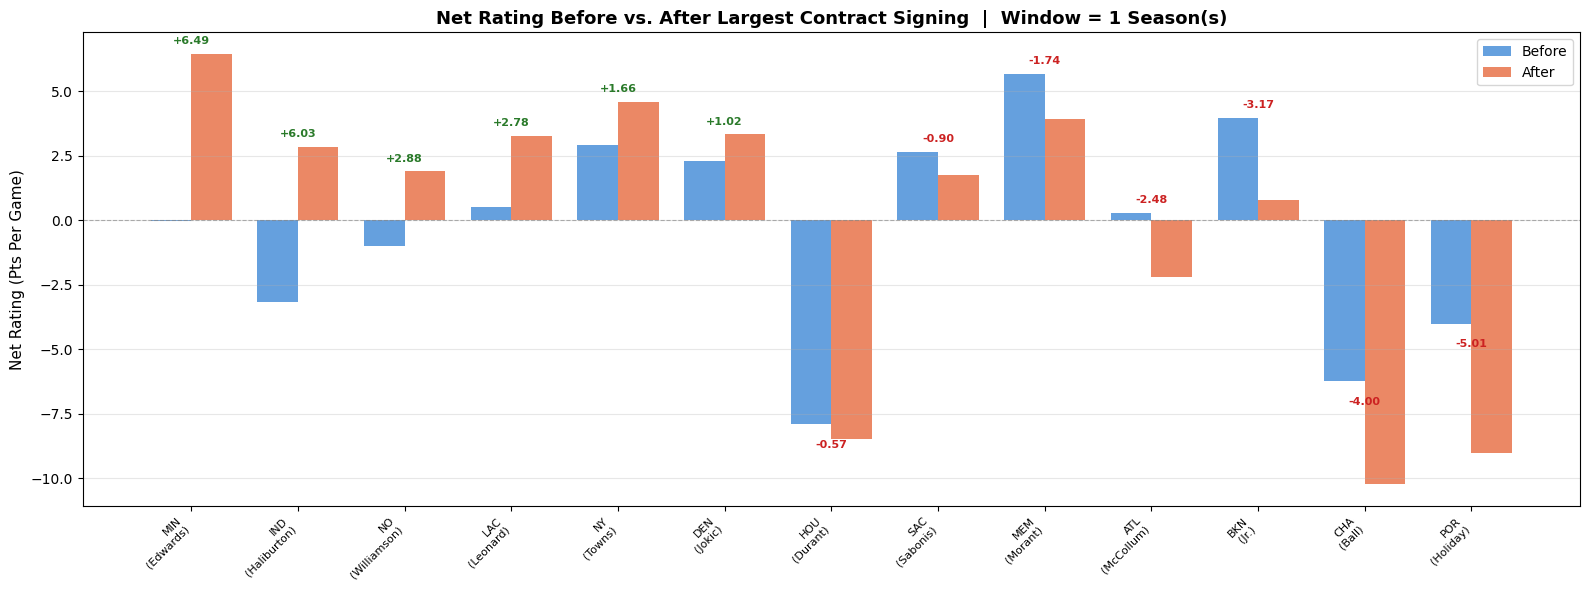

Saved: v2_before_after_net_rating.png


In [10]:
plot_df = results_df.sort_values('net_rating_change', ascending=False).reset_index(drop=True)

x_pos = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 6))

bars_before = ax.bar(x_pos - width/2, plot_df['before_net_rating'], width, label='Before', color='#4a90d9', alpha=0.85)
bars_after  = ax.bar(x_pos + width/2, plot_df['after_net_rating'],  width, label='After',  color='#e8734a', alpha=0.85)

# Label the change on top of each pair
for i, (_, row) in enumerate(plot_df.iterrows()):
    change   = row['net_rating_change']
    color    = '#2a7a2a' if change >= 0 else '#cc2222'
    label    = f'{change:+.2f}'
    top      = max(row['before_net_rating'], row['after_net_rating'])
    offset   = 0.3 if top >= 0 else -1.0
    ax.text(i, top + offset, label, ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

ax.set_xticks(x_pos)
ax.set_xticklabels(
    [f"{row['team']}\n({row['player'].split()[-1]})" for _, row in plot_df.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Net Rating (Pts Per Game)', fontsize=11)
ax.set_title(f'Net Rating Before vs. After Largest Contract Signing  |  Window = {WINDOW} Season(s)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v2_before_after_net_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v2_before_after_net_rating.png')

---
## Block 11 — Plot 2: Contract Size vs. Net Rating Change (Scatter + Regression Line)

- Each dot is one team
- X-axis: contract AAV in millions
- Y-axis: how much net rating changed after the signing
- The regression line shows the overall trend
- Compare the slope and R² visually to the V1 scatter — if the dots cluster tighter around the line, net rating is a cleaner signal than win rate

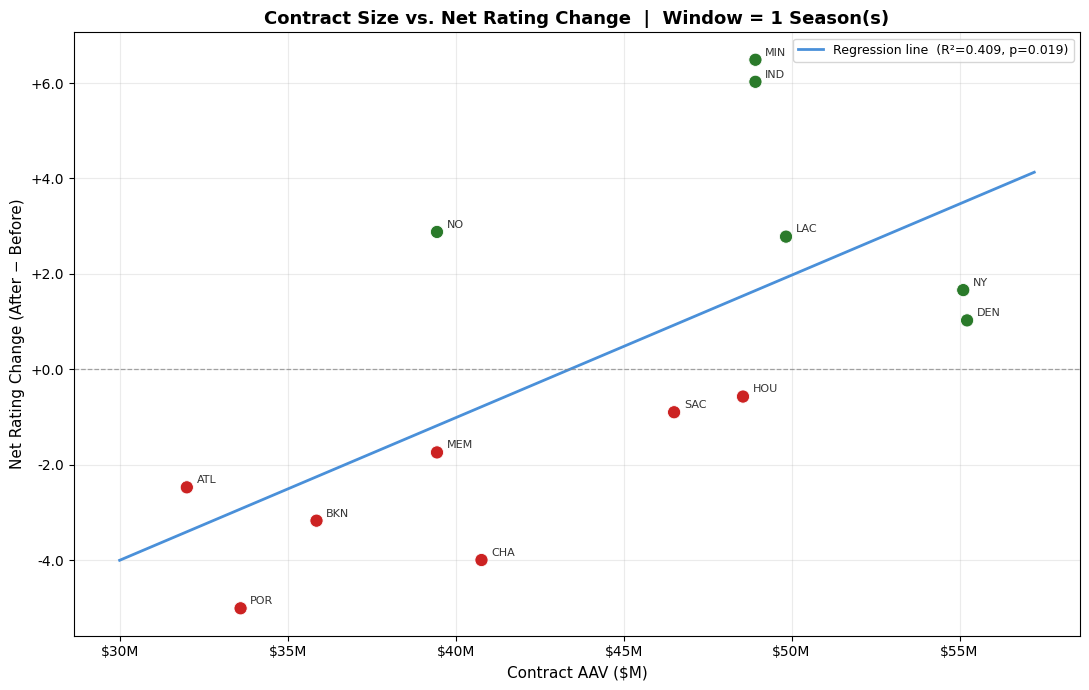

Saved: v2_contract_vs_net_rating_change.png


In [11]:
x = results_df['aav_millions'].values
y = results_df['net_rating_change'].values

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)
line_x = np.linspace(x.min() - 2, x.max() + 2, 100)
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#2a7a2a' if v >= 0 else '#cc2222' for v in y]
ax.scatter(x, y, c=colors, s=90, zorder=3, edgecolors='white', linewidths=0.6)

# Label each dot
for i, row in results_df.iterrows():
    ax.annotate(
        f"{row['team']}",
        (row['aav_millions'], row['net_rating_change']),
        textcoords='offset points', xytext=(7, 3),
        fontsize=8, color='#333333'
    )

# Regression line
ax.plot(line_x, line_y, color='#4a90d9', linewidth=2,
        label=f'Regression line  (R²={r_value**2:.3f}, p={p_value_reg:.3f})')

# Zero reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)

ax.set_xlabel('Contract AAV ($M)', fontsize=11)
ax.set_ylabel('Net Rating Change (After − Before)', fontsize=11)
ax.set_title(f'Contract Size vs. Net Rating Change  |  Window = {WINDOW} Season(s)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.1f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('v2_contract_vs_net_rating_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v2_contract_vs_net_rating_change.png')

---
## Block 12 — Plot 3: V1 vs. V2 Side-by-Side Comparison

- Shows win rate change (from V1) alongside net rating change (V2) for the same teams
- Useful for spotting teams where the two metrics *disagree* — e.g. a team that won more games but actually played worse (or vice versa)
- **Why this matters:** if the two metrics tell the same story, your findings are more robust

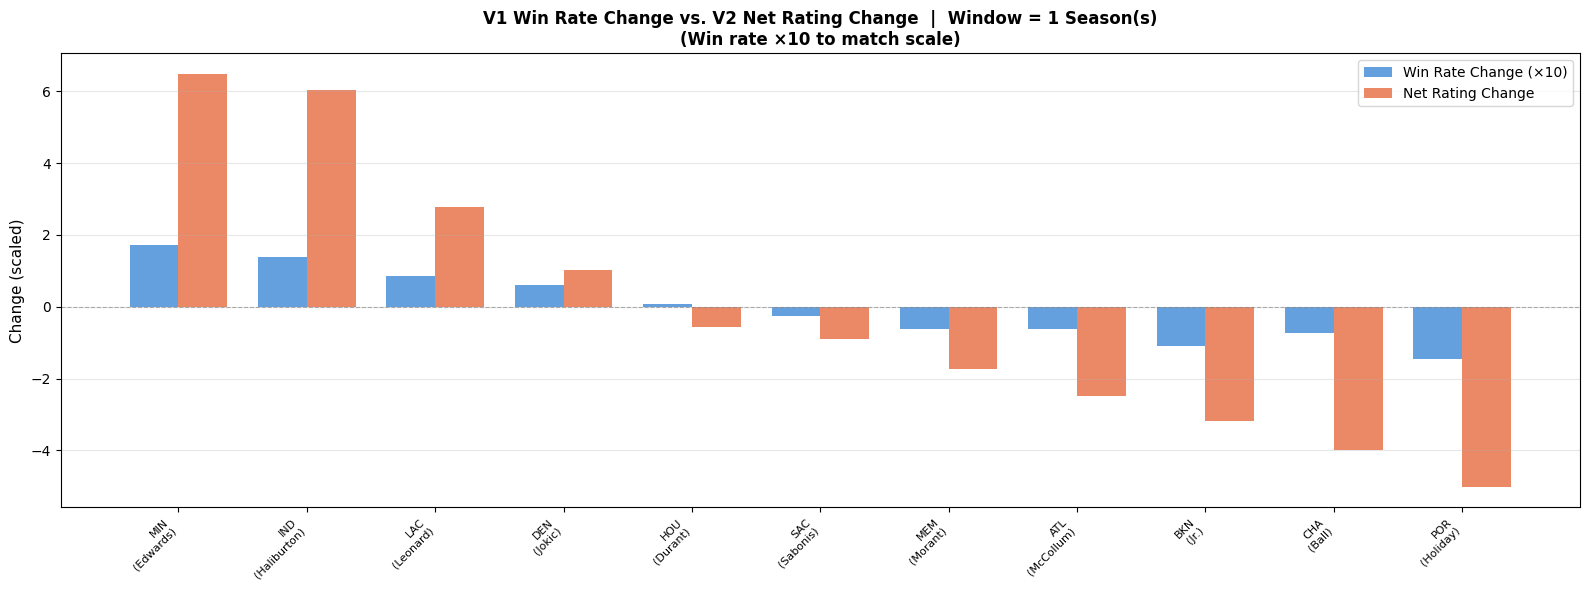

Saved: v2_v1_vs_v2_comparison.png

Note: Win rate change is multiplied by 10 only for visual scaling. Raw values are in the summary table.


In [12]:
# V1 results hardcoded from the executed V1 notebook (WINDOW=1)
v1_data = {
    'MIN': 0.1707, 'IND': 0.1394, 'LAC': 0.0854, 'DEN': 0.0610,
    'HOU': 0.0078, 'SAC': -0.0244, 'ATL': -0.0610, 'MEM': -0.0610,
    'CHA': -0.0732, 'BKN': -0.1105, 'POR': -0.1463
}

# Merge V1 win rate changes onto the V2 results
results_df['v1_win_rate_change'] = results_df['team'].map(v1_data)

# Keep only teams present in both
compare_df = results_df.dropna(subset=['v1_win_rate_change']).copy()
compare_df = compare_df.sort_values('net_rating_change', ascending=False).reset_index(drop=True)

x_pos = np.arange(len(compare_df))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 6))

# Scale win rate change to be visually comparable (multiply by 10 so it's in similar units to net rating)
bars_v1 = ax.bar(x_pos - width/2, compare_df['v1_win_rate_change'] * 10, width,
                 label='Win Rate Change (×10)', color='#4a90d9', alpha=0.85)
bars_v2 = ax.bar(x_pos + width/2, compare_df['net_rating_change'], width,
                 label='Net Rating Change', color='#e8734a', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(
    [f"{row['team']}\n({row['player'].split()[-1]})" for _, row in compare_df.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Change (scaled)', fontsize=11)
ax.set_title(f'V1 Win Rate Change vs. V2 Net Rating Change  |  Window = {WINDOW} Season(s)\n(Win rate ×10 to match scale)', fontsize=12, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v2_v1_vs_v2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v2_v1_vs_v2_comparison.png')
print('\nNote: Win rate change is multiplied by 10 only for visual scaling. Raw values are in the summary table.')

---
## Block 13 — Summary Table

- Clean printout of every team with both V1 and V2 numbers side by side
- The **Agreement** column flags whether win rate change and net rating change point in the same direction
- Disagreements are worth investigating — they could indicate a team that got lucky with wins, or suffered from a tough schedule

In [13]:
summary = results_df[['team', 'player', 'contract_start', 'aav_millions',
                       'before_net_rating', 'after_net_rating', 'net_rating_change',
                       'v1_win_rate_change']].copy()

summary = summary.sort_values('net_rating_change', ascending=False).reset_index(drop=True)

# Flag whether V1 and V2 agree on direction
summary['Agreement'] = summary.apply(
    lambda r: 'Yes' if (r['net_rating_change'] >= 0) == (r['v1_win_rate_change'] >= 0)
              else 'DISAGREE', axis=1
)

summary.columns = ['Team', 'Player', 'Start', 'AAV ($M)',
                   'Net Rtg Before', 'Net Rtg After', 'Net Rtg Change',
                   'Win Rt Change (V1)', 'V1/V2 Agree']

summary['AAV ($M)']          = summary['AAV ($M)'].map('${:.1f}M'.format)
summary['Net Rtg Before']    = summary['Net Rtg Before'].map('{:+.2f}'.format)
summary['Net Rtg After']     = summary['Net Rtg After'].map('{:+.2f}'.format)
summary['Net Rtg Change']    = summary['Net Rtg Change'].map('{:+.2f}'.format)
summary['Win Rt Change (V1)']= summary['Win Rt Change (V1)'].map(lambda v: f'{v:+.3f}' if pd.notna(v) else 'N/A')

print(f'V2 Summary  |  Window = {WINDOW} season(s)')
print('=' * 95)
print(summary.to_string(index=False))
print('=' * 95)
print(f'\nTeams that IMPROVED net rating: {(results_df["net_rating_change"] > 0).sum()}')
print(f'Teams that DECLINED net rating: {(results_df["net_rating_change"] < 0).sum()}')
print(f'Average change:                 {results_df["net_rating_change"].mean():+.3f}')
disagree = summary[summary['V1/V2 Agree'] == 'DISAGREE']
if len(disagree) > 0:
    print(f'\nTeams where V1 and V2 DISAGREE on direction: {list(disagree["Team"])}')

V2 Summary  |  Window = 1 season(s)
Team             Player  Start AAV ($M) Net Rtg Before Net Rtg After Net Rtg Change Win Rt Change (V1) V1/V2 Agree
 MIN    Anthony Edwards   2024   $48.9M          -0.04         +6.45          +6.49             +0.171         Yes
 IND  Tyrese Haliburton   2024   $48.9M          -3.18         +2.84          +6.03             +0.139         Yes
  NO    Zion Williamson   2023   $39.4M          -0.99         +1.89          +2.88                N/A    DISAGREE
 LAC      Kawhi Leonard   2024   $49.8M          +0.50         +3.28          +2.78             +0.085         Yes
  NY Karl-Anthony Towns   2024   $55.1M          +2.93         +4.58          +1.66                N/A    DISAGREE
 DEN       Nikola Jokic   2023   $55.2M          +2.31         +3.33          +1.02             +0.061         Yes
 HOU       Kevin Durant   2022   $48.6M          -7.90         -8.48          -0.57             +0.008    DISAGREE
 SAC   Domantas Sabonis   2024   $46.5M     